<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/mountain_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create the environment
env = gym.make("MountainCar-v0")

# Discretization: We divide the continuous space into bins to use a Q-Table
# MountainCar state is (position, velocity)
def get_discrete_state(state):
    # Defining how many buckets to divide each state into
    state_space_size = [20, 20]
    # Ranges of the environment
    low = env.observation_space.low
    high = env.observation_space.high

    # Calculate the size of each bucket
    state_window = (high - low) / state_space_size

    # Return the discrete index
    discrete_state = ((state - low) / state_window).astype(int)
    return tuple(discrete_state)

In [38]:
import moviepy.editor as mp
!pip install moviepy

In [26]:
# The state space is now 20x20, and there are 3 possible actions
q_table = np.random.uniform(low=-2, high=0, size=(20, 20, 3))

# Hyperparameters
learning_rate = 0.1
discount = 0.95
episodes = 20000
epsilon = 0.5 # Exploration rate

In [32]:
rewards_per_episode = []

for episode in range(episodes):
    discrete_state = get_discrete_state(env.reset()[0])
    done = False
    # Tracking the highest position reached by the car for this episode
    highest_position = -1.2
    episode_reward = 0

    while not done:
        # Exploration vs Exploitation
        if np.random.random() > epsilon:
            action = np.argmax(q_table[discrete_state])
        else:
            action = np.random.randint(0, 3)

        new_state, reward, terminated, truncated, _ = env.step(action)
        new_discrete_state = get_discrete_state(new_state)

        # Update highest position
        if new_state[0] > highest_position:
            highest_position = new_state[0]

        # Q-Learning Update
        max_future_q = np.max(q_table[new_discrete_state])
        current_q = q_table[discrete_state + (action,)]

        # The Bellman Equation
        new_q = (1 - learning_rate) * current_q + learning_rate * (reward + discount * max_future_q)
        q_table[discrete_state + (action,)] = new_q

        discrete_state = new_discrete_state
        episode_reward += reward
        done = terminated or truncated

    rewards_per_episode.append(episode_reward)

    # Epsilon decay to reduce exploration over time
    epsilon *= 0.999

    # At the end of every 500 episodes, print the result:
    if episode % 500 == 0:
        print(f"Episode: {episode}, Highest Position: {highest_position:.2f}")

print("Training finished.")

Episode: 0, Highest Position: -0.33
Episode: 500, Highest Position: 0.02
Episode: 1000, Highest Position: 0.19
Episode: 1500, Highest Position: 0.32
Episode: 2000, Highest Position: 0.50
Episode: 2500, Highest Position: 0.13
Episode: 3000, Highest Position: 0.22
Episode: 3500, Highest Position: 0.51
Episode: 4000, Highest Position: 0.50
Episode: 4500, Highest Position: 0.52
Episode: 5000, Highest Position: 0.52
Episode: 5500, Highest Position: 0.25
Episode: 6000, Highest Position: 0.53
Episode: 6500, Highest Position: 0.53
Episode: 7000, Highest Position: 0.53
Episode: 7500, Highest Position: 0.53
Episode: 8000, Highest Position: 0.52
Episode: 8500, Highest Position: 0.51
Episode: 9000, Highest Position: 0.52
Episode: 9500, Highest Position: 0.52
Episode: 10000, Highest Position: 0.48
Episode: 10500, Highest Position: 0.52
Episode: 11000, Highest Position: 0.51
Episode: 11500, Highest Position: 0.52
Episode: 12000, Highest Position: 0.52
Episode: 12500, Highest Position: 0.52
Episode: 

In [33]:
# Add this BEFORE the while loop in Cell 3
highest_position = -1.2

# Inside the while loop, add this after the step:
if new_state[0] > highest_position:
    highest_position = new_state[0]

# At the end of every 500 episodes, print the result:
if episode % 500 == 0:
    print(f"Episode: {episode}, Highest Position: {highest_position:.2f}")

In [34]:
import numpy as np

# Save the Q-table to a file
np.save("mountain_car_qtable.npy", q_table)

# To load it later:
# q_table = np.load("mountain_car_qtable.npy")

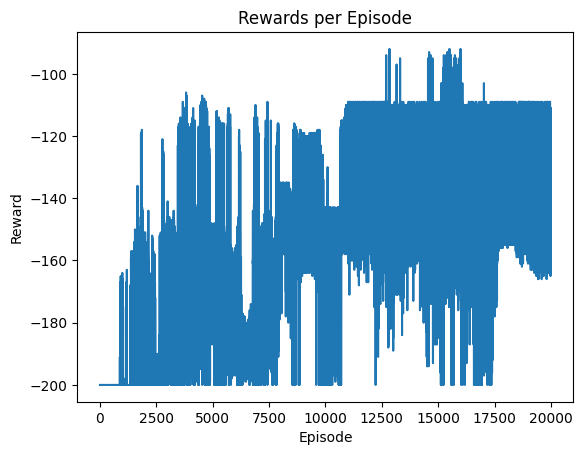

In [35]:
# Plot rewards per episode to visualize training progress
plt.plot(rewards_per_episode)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Rewards per Episode')
plt.show()

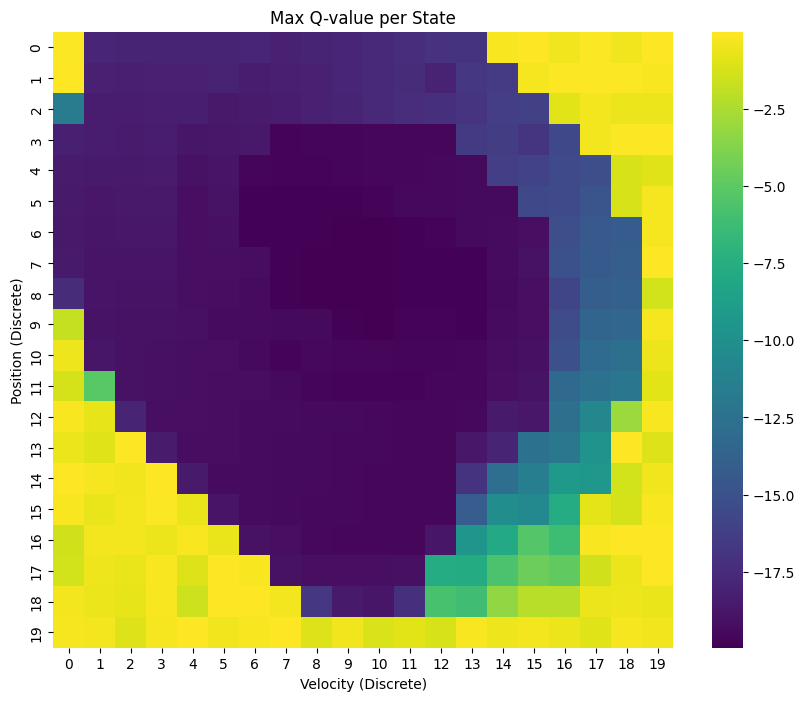

In [36]:
import seaborn as sns

# Visualize the Q-table (e.g., as a heatmap for one action or the max Q-value)
plt.figure(figsize=(10, 8))
sns.heatmap(np.max(q_table, axis=2), cmap='viridis')
plt.xlabel('Velocity (Discrete)')
plt.ylabel('Position (Discrete)')
plt.title('Max Q-value per State')
plt.show()

In [39]:
# Testing the trained agent

test_env = gym.make("MountainCar-v0", render_mode="rgb_array") # Use render_mode="rgb_array" to collect frames

discrete_state = get_discrete_state(test_env.reset()[0])
done = False

goal_reached = False
frames = [] # List to store frames for video recording

while not done:
    frames.append(test_env.render())
    action = np.argmax(q_table[discrete_state]) # Take action with highest Q-value
    new_state, reward, terminated, truncated, _ = test_env.step(action)
    discrete_state = get_discrete_state(new_state)

    if new_state[0] >= 0.5: # Check if the car reached the goal position
        goal_reached = True

    done = terminated or truncated

test_env.close()

if goal_reached:
    print("SUCCESS: The agent reached the top of the mountain!")
else:
    print("FAILURE: The agent did not reach the top of the mountain.")

# Save the frames as a video
if frames:
    clip = mp.ImageSequenceClip(frames, fps=30) # Adjust fps as needed
    clip.write_videofile("mountain_car_qlearning.mp4", codec="libx264")
    print("Video saved as mountain_car_qlearning.mp4")
else:
    print("No frames were collected for video recording.")


SUCCESS: The agent reached the top of the mountain!
Moviepy - Building video mountain_car_qlearning.mp4.
Moviepy - Writing video mountain_car_qlearning.mp4



Moviepy - Done !
Moviepy - video ready mountain_car_qlearning.mp4
Video saved as mountain_car_qlearning.mp4


In [40]:
from IPython.display import Video

video_path = "mountain_car_qlearning.mp4"
# Check if the video file exists before trying to display it
import os
if os.path.exists(video_path):
    display(Video(video_path, embed=True))
else:
    print(f"Video file not found at {video_path}")
